# Baseline 1: ResNet18 + Prototypical Network (Few-Shot Learning)

This notebook runs **1-shot, 5-shot, and 10-shot** experiments.

## Imports

In [1]:
import os, random
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Image Transform

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Few-Shot Dataset (Episodic Sampling)

In [3]:
class FewShotDataset:
    def __init__(self, root_dir, transform):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_images = {
            cls: os.listdir(os.path.join(root_dir, cls))
            for cls in self.classes
        }

    def sample_episode(self, n_way, k_shot, q_query):
        support_images, support_labels = [], []
        query_images, query_labels = [], []

        selected_classes = random.sample(self.classes, n_way)

        for label, cls in enumerate(selected_classes):
            # Handle insufficient images by reusing available ones
            images = self.class_to_images[cls]
            if len(images) < k_shot + q_query:
                print(f"⚠️ Not enough images in class '{cls}'. Reusing available images.")
                images = (images * ((k_shot + q_query) // len(images) + 1))[:k_shot + q_query]

            sampled_images = random.sample(images, k_shot + q_query)
            cls_path = os.path.join(self.root_dir, cls)

            for img_name in sampled_images[:k_shot]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                support_images.append(self.transform(img))
                support_labels.append(label)

            for img_name in sampled_images[k_shot:]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                query_images.append(self.transform(img))
                query_labels.append(label)

        return (
            torch.stack(support_images),
            torch.tensor(support_labels),
            torch.stack(query_images),
            torch.tensor(query_labels)
        )

## ResNet18 Encoder

In [4]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)

## Prototypical Network

In [5]:
class ProtoNet(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, support_x, support_y, query_x):
        support_emb = self.encoder(support_x)
        query_emb = self.encoder(query_x)

        prototypes = []
        for c in torch.unique(support_y):
            prototypes.append(support_emb[support_y == c].mean(0))
        prototypes = torch.stack(prototypes)

        distances = torch.cdist(query_emb, prototypes)
        return -distances

## Training & Evaluation

In [6]:
def train_and_evaluate(k_shot):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_data = FewShotDataset("clean_dataset/train", transform)
    val_data = FewShotDataset("clean_dataset/val", transform)

    model = ProtoNet(ResNet18Encoder()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Train
    model.train()
    for episode in range(100):
        print(f"Training episode {episode + 1}/100...")
        sx, sy, qx, qy = train_data.sample_episode(4, k_shot, 10)
        sx, sy, qx, qy = sx.to(device), sy.to(device), qx.to(device), qy.to(device)

        scores = model(sx, sy, qx)
        loss = F.cross_entropy(scores, qy)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for eval_episode in range(50):
            print(f"Evaluating episode {eval_episode + 1}/50...")
            sx, sy, qx, qy = val_data.sample_episode(4, k_shot, 10)
            sx, sy, qx, qy = sx.to(device), sy.to(device), qx.to(device), qy.to(device)
            preds = model(sx, sy, qx).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(qy.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, cm

## Run 1-shot, 5-shot, 10-shot Experiments

Starting 1-shot evaluation...


c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training episode 37/100...
Training e

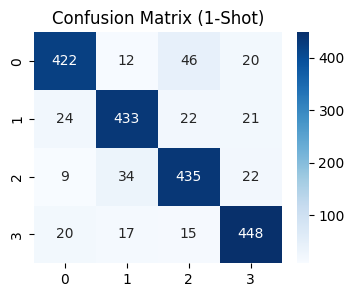

Completed 1-shot evaluation.

Starting 5-shot evaluation...


c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training episode 37/100...
Training e

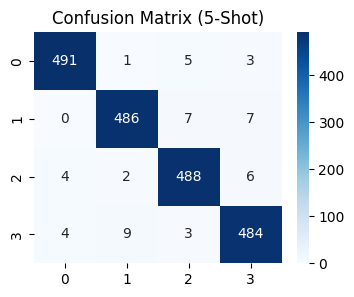

Completed 5-shot evaluation.

Starting 10-shot evaluation...


c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training episode 37/100...
Training e

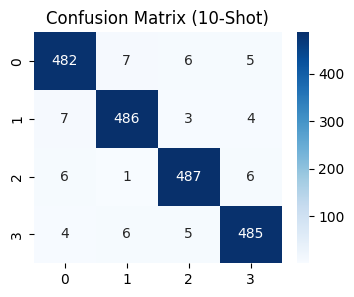

Completed 10-shot evaluation.



In [7]:
for k in [1, 5, 10]:
    print(f"Starting {k}-shot evaluation...")
    acc, cm = train_and_evaluate(k)
    print(f"\n{k}-Shot Accuracy: {acc:.4f}")
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({k}-Shot)")
    plt.show()
    print(f"Completed {k}-shot evaluation.\n")

In [15]:
import pandas as pd

data = {
    'Shots': [1, 5, 10],
    'Accuracy': [0.8690, 0.9745, 0.9700]
}

df = pd.DataFrame(data)

# Derive Percentage from Accuracy
df["Percentage"] = df["Accuracy"]

styled_df = (
    df.style
      .set_caption("Baseline 1: ResNet18 + ProtoNet")
      .format({
          "Accuracy": "{:.4f}",
          "Percentage": "{:.2%}"
      })
      .set_properties(**{"text-align": "center"})
)

styled_df


,Shots,Accuracy,Percentage
0,1,0.8690,86.90%
1,5,0.9745,97.45%
2,10,0.9700,97.00%
